# 🌧️ Clasificación de Precipitación con TNN - Dataset JUN
**Tarea:** Clasificación multiclase (3 clases) — Balanceo por submuestreo de clase 0  
**Horizontes:** 1h, 3h y 6h  
**Arquitectura:** Temporal Neural Network (Conv1D)  
**Clases:**
- `0` — Sin lluvia: 0 – 0.1 mm/h
- `1` — Lluvia leve: 0.1 – 1 mm/h
- `2` — Lluvia fuerte: > 1 mm/h

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, Dense, Dropout, Flatten,
    MaxPooling1D, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

print(f'TensorFlow version: {tf.__version__}')
print(f'Pandas version: {pd.__version__}')

TensorFlow version: 2.21.0
Pandas version: 2.3.3


## 2. Carga y Resampleo del Dataset

In [3]:
FILE_PATH = '../../Datasets/JUN_consolid_f15.csv'
RAIN_COL  = 'Rain_mm_Tot'

df = pd.read_csv(
    FILE_PATH,
    parse_dates=['TIMESTAMP'],
    index_col='TIMESTAMP',
    na_values=['NA', 'NaN', '']
)

# Resampleo 15min → 1h
other_cols = [c for c in df.columns if c != RAIN_COL]
df_hourly  = pd.concat([
    df[other_cols].resample('1H').mean(),
    df[[RAIN_COL]].resample('1H').sum()
], axis=1)

print(f'Shape original : {df.shape}')
print(f'Shape horario  : {df_hourly.shape}')
print(f'Rango fechas   : {df_hourly.index.min()} → {df_hourly.index.max()}')

Shape original : (375325, 53)
Shape horario  : (93832, 53)
Rango fechas   : 2015-06-22 15:00:00 → 2026-03-06 06:00:00


## 3. Creación de Clases

| Clase | Etiqueta | Umbral |
|-------|----------|--------|
| 0 | Sin lluvia | < 0.1 mm/h |
| 1 | Lluvia leve | 0.1 – 1.0 mm/h |
| 2 | Lluvia fuerte | > 1.0 mm/h |

=== Distribución de clases (dataset completo) ===
  Clase 0 (Sin lluvia):  74241 (79.1%)
  Clase 1 (Lluvia leve):  15490 (16.5%)
  Clase 2 (Lluvia fuerte):   4101 (4.4%)


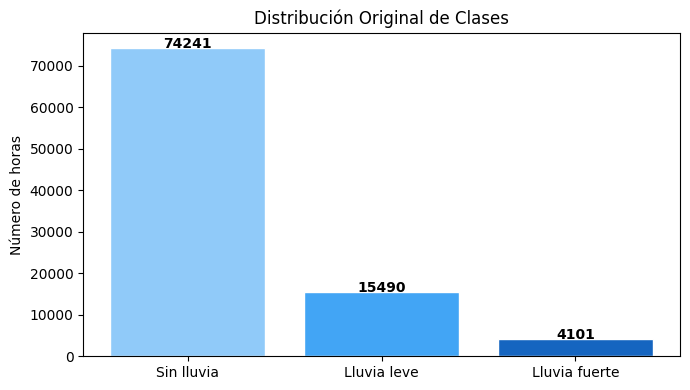

In [4]:
# ============================================================
# UMBRALES
# ============================================================
UMBRAL_LEVE   = 0.1
UMBRAL_FUERTE = 1.0
N_CLASSES     = 3
class_labels  = {0: 'Sin lluvia', 1: 'Lluvia leve', 2: 'Lluvia fuerte'}
colors        = ['#90CAF9', '#42A5F5', '#1565C0']

def clasificar_lluvia(mm):
    if mm < UMBRAL_LEVE:   return 0
    elif mm <= UMBRAL_FUERTE: return 1
    else:                  return 2

df_hourly['rain_class'] = df_hourly[RAIN_COL].apply(clasificar_lluvia)

class_counts = df_hourly['rain_class'].value_counts().sort_index()
print('=== Distribución de clases (dataset completo) ===')
for cls, cnt in class_counts.items():
    print(f'  Clase {cls} ({class_labels[cls]}): {cnt:6d} ({cnt/len(df_hourly)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([class_labels[i] for i in range(3)], class_counts.values, color=colors, edgecolor='white')
ax.set_title('Distribución Original de Clases')
ax.set_ylabel('Número de horas')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_clases_original.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Preprocesamiento de Features

In [5]:
FEATURES = [
    'SlrkW_Avg', 'SlrMJ_Tot', 'WS_ms_Avg', 'NR_Wm2_Avg',
    'VW', 'VW_2', 'VW_3', 'WindDir', 'Rain_mm_Tot'
]

data = df_hourly[FEATURES].copy()
data = data.interpolate(method='linear', limit=6).dropna()

# Features temporales cíclicas
data['hour_sin']  = np.sin(2 * np.pi * data.index.hour / 24)
data['hour_cos']  = np.cos(2 * np.pi * data.index.hour / 24)
data['month_sin'] = np.sin(2 * np.pi * data.index.month / 12)
data['month_cos'] = np.cos(2 * np.pi * data.index.month / 12)

# Lags de lluvia
data['Rain_lag1'] = data['Rain_mm_Tot'].shift(1)
data['Rain_lag2'] = data['Rain_mm_Tot'].shift(2)
data['Rain_lag3'] = data['Rain_mm_Tot'].shift(3)

# Alinear etiquetas
labels = df_hourly['rain_class'].reindex(data.index)
data   = data.dropna()
labels = labels.reindex(data.index)

print(f'Shape features : {data.shape}')
print(f'Num. features  : {data.shape[1]}')

Shape features : (71302, 16)
Num. features  : 16


## 5. Normalización y División Temporal

In [6]:
# ============================================================
# PARÁMETROS GLOBALES
# ============================================================
LOOK_BACK  = 24
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
EPOCHS     = 100
BATCH_SIZE = 32
PATIENCE   = 10

n_total    = len(data)
n_train    = int(n_total * TRAIN_FRAC)
n_val      = int(n_total * VAL_FRAC)
n_features = data.shape[1]

scaler      = MinMaxScaler(feature_range=(0, 1))
data_np     = data.values.astype(np.float32)
labels_np   = labels.values.astype(np.int32)

scaler.fit(data_np[:n_train])
data_scaled = scaler.transform(data_np)

print(f'Total    : {n_total}')
print(f'Train    : {n_train}')
print(f'Val      : {n_val}')
print(f'Test     : {n_total - n_train - n_val}')
print(f'Features : {n_features}')

Total    : 71302
Train    : 49911
Val      : 10695
Test     : 10696
Features : 16


## 6. Funciones: Secuencias + Balanceo por Submuestreo

> **Estrategia:** Se submuestrea aleatoriamente la clase mayoritaria (Sin lluvia) en el conjunto de **train únicamente**. Val y Test mantienen la distribución real para evaluación honesta.

In [7]:
def create_sequences_clf(data_scaled, labels, look_back, horizon=1):
    """Crea ventanas deslizantes para clasificación."""
    X, y = [], []
    n = len(data_scaled)
    for i in range(n - look_back - horizon + 1):
        X.append(data_scaled[i : i + look_back, :])
        y.append(labels[i + look_back + horizon - 1])
    return np.array(X), np.array(y)


def undersample_train(X_train, y_train, random_state=42):
    """
    Submuestreo de la clase mayoritaria para balancear el train.
    Iguala todas las clases al tamaño de la clase minoritaria.
    """
    np.random.seed(random_state)
    classes, counts = np.unique(y_train, return_counts=True)
    min_count = counts.min()
    
    print(f'\n=== Balanceo por Submuestreo ===')
    print(f'Tamaño objetivo por clase: {min_count}')
    
    indices = []
    for cls in classes:
        cls_idx = np.where(y_train == cls)[0]
        sampled = np.random.choice(cls_idx, size=min_count, replace=False)
        indices.append(sampled)
        print(f'  Clase {cls} ({class_labels[cls]}): {len(cls_idx)} → {min_count}')
    
    idx_balanced = np.concatenate(indices)
    np.random.shuffle(idx_balanced)
    
    print(f'Total train balanceado: {len(idx_balanced)}')
    return X_train[idx_balanced], y_train[idx_balanced]


def build_tnn_classifier(look_back, n_features, n_classes,
                          filters1=64, filters2=128, kernel_size=3,
                          dropout=0.3, lr=1e-3):
    """TNN (Conv1D) para clasificación multiclase."""
    model = Sequential([
        Conv1D(filters=filters1, kernel_size=kernel_size, activation='relu',
               padding='same', input_shape=(look_back, n_features)),
        BatchNormalization(), Dropout(dropout),

        Conv1D(filters=filters2, kernel_size=kernel_size, activation='relu', padding='same'),
        BatchNormalization(), Dropout(dropout),

        Conv1D(filters=filters2, kernel_size=kernel_size, activation='relu', padding='same'),
        BatchNormalization(), MaxPooling1D(pool_size=2), Dropout(dropout),

        Flatten(),
        Dense(128, activation='relu'), Dropout(dropout),
        Dense(64,  activation='relu'), Dropout(dropout),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def evaluate_model(model, X_test, y_test, horizon_label):
    """Predicción, métricas y gráficos para un horizonte."""
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true      = y_test

    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro')
    f1_wei = f1_score(y_true, y_pred, average='weighted')

    print(f'\n📊 Métricas — TNN Clasificación {horizon_label}')
    print(f'   Accuracy    : {acc:.4f}')
    print(f'   F1 Macro    : {f1_mac:.4f}')
    print(f'   F1 Weighted : {f1_wei:.4f}')
    print(f'\n{"="*50}')
    print(classification_report(
        y_true, y_pred,
        target_names=[class_labels[i] for i in range(N_CLASSES)]
    ))

    # Matriz de confusión
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ConfusionMatrixDisplay(cm,      display_labels=[class_labels[i] for i in range(N_CLASSES)]).plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title('Conteos')
    ConfusionMatrixDisplay(cm_norm, display_labels=[class_labels[i] for i in range(N_CLASSES)]).plot(ax=axes[1], colorbar=False, cmap='Blues')
    axes[1].set_title('Normalizada')
    plt.suptitle(f'Matriz de Confusión — {horizon_label}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'confusion_{horizon_label.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

    return {'horizon': horizon_label, 'Accuracy': acc, 'F1_Macro': f1_mac, 'F1_Weighted': f1_wei,
            'y_pred': y_pred, 'y_true': y_true, 'y_prob': y_pred_prob}


print('✅ Funciones definidas')

✅ Funciones definidas


---
## 7. MODELO 1 — Horizonte 1h

In [8]:
HORIZON = 1

X_all, y_all = create_sequences_clf(data_scaled, labels_np, LOOK_BACK, HORIZON)

X_train_raw = X_all[:n_train];            y_train_raw = y_all[:n_train]
X_val       = X_all[n_train:n_train+n_val]; y_val     = y_all[n_train:n_train+n_val]
X_test      = X_all[n_train+n_val:];      y_test      = y_all[n_train+n_val:]

# Balanceo solo en train
X_train, y_train = undersample_train(X_train_raw, y_train_raw)

# One-hot encoding
y_train_cat = to_categorical(y_train, N_CLASSES)
y_val_cat   = to_categorical(y_val,   N_CLASSES)

print(f'\nTrain balanceado : {X_train.shape}')
print(f'Val              : {X_val.shape}')
print(f'Test             : {X_test.shape}')


=== Balanceo por Submuestreo ===
Tamaño objetivo por clase: 2275
  Clase 0 (Sin lluvia): 39053 → 2275
  Clase 1 (Lluvia leve): 8583 → 2275
  Clase 2 (Lluvia fuerte): 2275 → 2275
Total train balanceado: 6825

Train balanceado : (6825, 24, 16)
Val              : (10695, 24, 16)
Test             : (10672, 24, 16)


In [9]:
model_1h = build_tnn_classifier(LOOK_BACK, n_features, N_CLASSES)
model_1h.summary()

callbacks_1h = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history_1h = model_1h.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_1h,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 64)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 24, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,587 (1.08 MB)

 Trainable params: 282,947 (1.08 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.4473 - loss: 1.1348 - val_accuracy: 0.4538 - val_loss: 1.0371 - learning_rate: 0.0010
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5067 - loss: 0.9919 - val_accuracy: 0.6243 - val_loss: 0.8135 - learning_rate: 0.0010
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5396 - loss: 0.9456 - val_accuracy: 0.6478 - val_loss: 0.8383 - learning_rate: 0.0010
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5495 - loss: 0.9270 - val_accuracy: 0.3398 - val_loss: 1.3465 - learning_rate: 0.0010
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5711 - loss: 0.9014 - val_accuracy: 0.6216 - val_loss: 0.8697 - learning_rate: 0.0010
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5958 - loss: 0.8729 - val_accuracy: 0.7241 - val_loss: 0.7309 - learning_rate: 0.0010
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.6038 - l

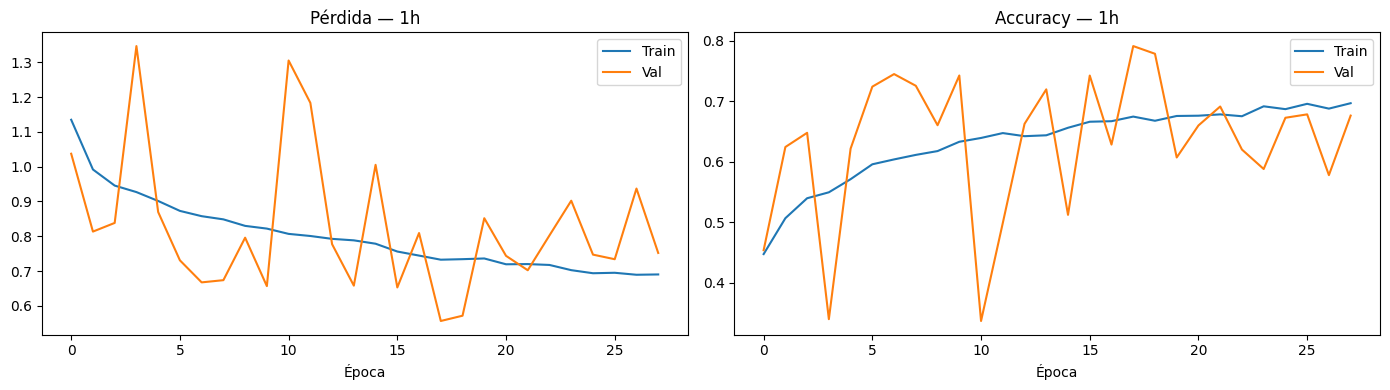

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_1h.history['loss'],     label='Train'); axes[0].plot(history_1h.history['val_loss'], label='Val')
axes[0].set_title('Pérdida — 1h'); axes[0].set_xlabel('Época'); axes[0].legend()
axes[1].plot(history_1h.history['accuracy'], label='Train'); axes[1].plot(history_1h.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy — 1h'); axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout()
plt.savefig('curvas_1h.png', dpi=120, bbox_inches='tight')
plt.show()


📊 Métricas — TNN Clasificación 1 Hora
   Accuracy    : 0.7444
   F1 Macro    : 0.5385
   F1 Weighted : 0.7565

               precision    recall  f1-score   support

   Sin lluvia       0.91      0.84      0.88      8254
  Lluvia leve       0.36      0.28      0.32      1713
Lluvia fuerte       0.30      0.73      0.42       705

     accuracy                           0.74     10672
    macro avg       0.52      0.62      0.54     10672
 weighted avg       0.78      0.74      0.76     10672



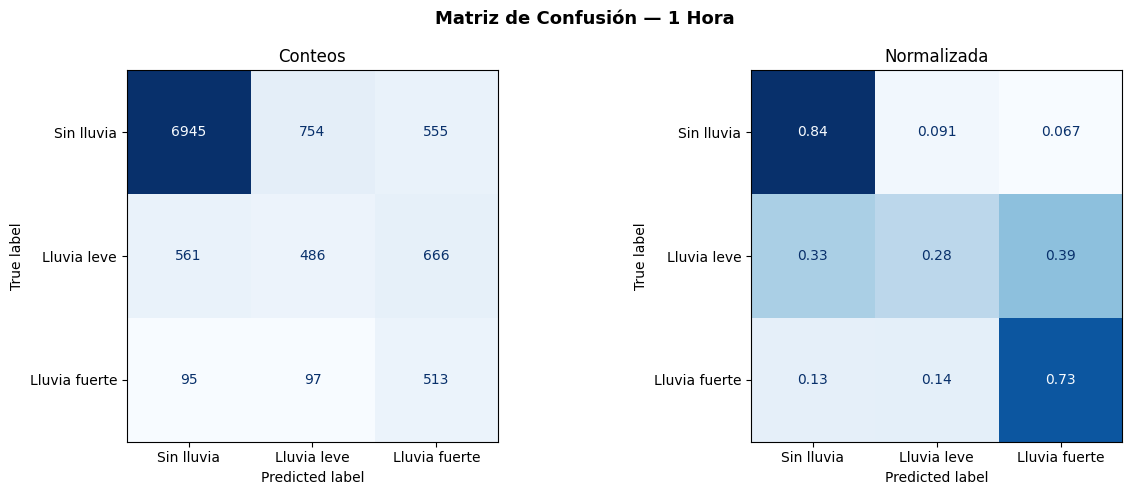

In [11]:
results_1h = evaluate_model(model_1h, X_test, y_test, '1 Hora')
model_1h.save('tnn_clf_balanced_1h.keras')

---
## 8. MODELO 2 — Horizonte 3h

In [12]:
HORIZON = 3

X_all_3h, y_all_3h = create_sequences_clf(data_scaled, labels_np, LOOK_BACK, HORIZON)

X_train_raw_3h = X_all_3h[:n_train];              y_train_raw_3h = y_all_3h[:n_train]
X_val_3h       = X_all_3h[n_train:n_train+n_val]; y_val_3h       = y_all_3h[n_train:n_train+n_val]
X_test_3h      = X_all_3h[n_train+n_val:];        y_test_3h      = y_all_3h[n_train+n_val:]

# Balanceo solo en train
X_train_3h, y_train_3h = undersample_train(X_train_raw_3h, y_train_raw_3h)

y_train_cat_3h = to_categorical(y_train_3h, N_CLASSES)
y_val_cat_3h   = to_categorical(y_val_3h,   N_CLASSES)

print(f'\nTrain balanceado : {X_train_3h.shape}')
print(f'Val              : {X_val_3h.shape}')
print(f'Test             : {X_test_3h.shape}')


=== Balanceo por Submuestreo ===
Tamaño objetivo por clase: 2275
  Clase 0 (Sin lluvia): 39053 → 2275
  Clase 1 (Lluvia leve): 8583 → 2275
  Clase 2 (Lluvia fuerte): 2275 → 2275
Total train balanceado: 6825

Train balanceado : (6825, 24, 16)
Val              : (10695, 24, 16)
Test             : (10670, 24, 16)


In [13]:
model_3h = build_tnn_classifier(LOOK_BACK, n_features, N_CLASSES)

callbacks_3h = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history_3h = model_3h.fit(
    X_train_3h, y_train_cat_3h,
    validation_data=(X_val_3h, y_val_cat_3h),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_3h,
    verbose=1
)

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.4286 - loss: 1.1610 - val_accuracy: 0.0596 - val_loss: 2.5902 - learning_rate: 0.0010
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4857 - loss: 1.0148 - val_accuracy: 0.2120 - val_loss: 1.3960 - learning_rate: 0.0010
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5084 - loss: 0.9804 - val_accuracy: 0.4382 - val_loss: 1.1185 - learning_rate: 0.0010
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5213 - loss: 0.9634 - val_accuracy: 0.4571 - val_loss: 0.9935 - learning_rate: 0.0010
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5311 - loss: 0.9489 - val_accuracy: 0.4736 - val_loss: 1.0910 - learning_rate: 0.0010
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5399 - loss: 0.9399 - val_accuracy: 0.6065 - val_loss: 0.9020 - learning_rate: 0.0010
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5493 - 

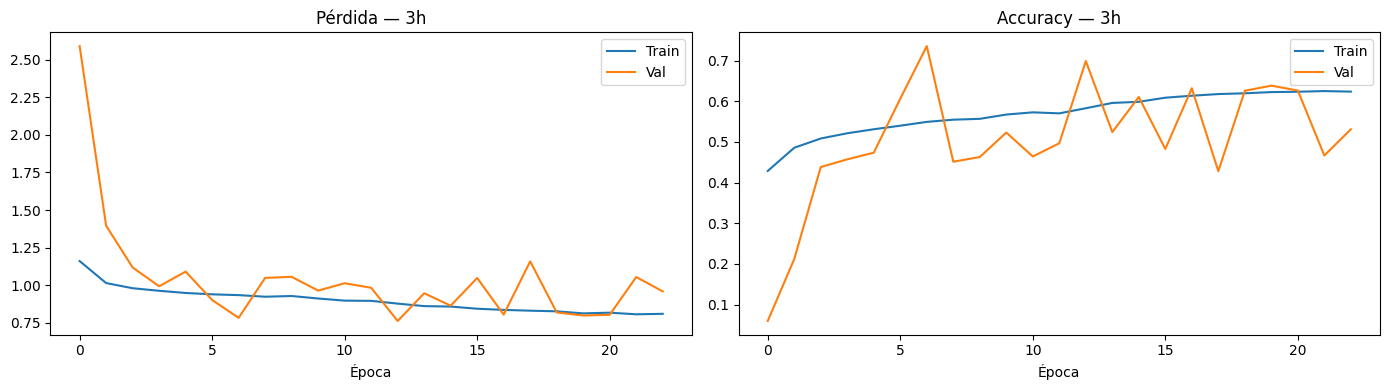

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_3h.history['loss'],     label='Train'); axes[0].plot(history_3h.history['val_loss'], label='Val')
axes[0].set_title('Pérdida — 3h'); axes[0].set_xlabel('Época'); axes[0].legend()
axes[1].plot(history_3h.history['accuracy'], label='Train'); axes[1].plot(history_3h.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy — 3h'); axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout()
plt.savefig('curvas_3h.png', dpi=120, bbox_inches='tight')
plt.show()


📊 Métricas — TNN Clasificación 3 Horas
   Accuracy    : 0.6170
   F1 Macro    : 0.4554
   F1 Weighted : 0.6614

               precision    recall  f1-score   support

   Sin lluvia       0.89      0.66      0.76      8252
  Lluvia leve       0.28      0.49      0.36      1713
Lluvia fuerte       0.18      0.40      0.25       705

     accuracy                           0.62     10670
    macro avg       0.45      0.52      0.46     10670
 weighted avg       0.75      0.62      0.66     10670



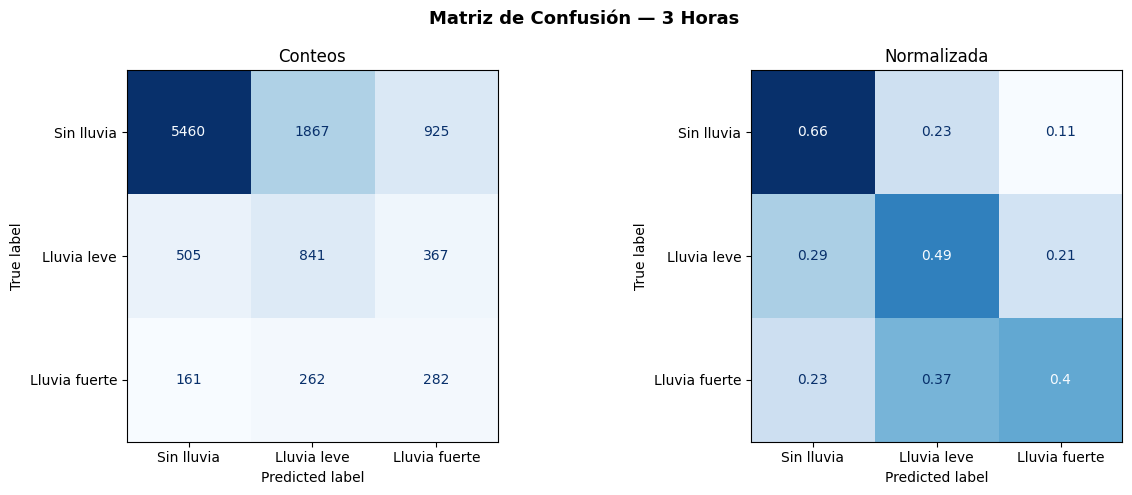

In [15]:
results_3h = evaluate_model(model_3h, X_test_3h, y_test_3h, '3 Horas')
model_3h.save('tnn_clf_balanced_3h.keras')

---
## 9. MODELO 3 — Horizonte 6h

In [16]:
HORIZON = 6

X_all_6h, y_all_6h = create_sequences_clf(data_scaled, labels_np, LOOK_BACK, HORIZON)

X_train_raw_6h = X_all_6h[:n_train];              y_train_raw_6h = y_all_6h[:n_train]
X_val_6h       = X_all_6h[n_train:n_train+n_val]; y_val_6h       = y_all_6h[n_train:n_train+n_val]
X_test_6h      = X_all_6h[n_train+n_val:];        y_test_6h      = y_all_6h[n_train+n_val:]

# Balanceo solo en train
X_train_6h, y_train_6h = undersample_train(X_train_raw_6h, y_train_raw_6h)

y_train_cat_6h = to_categorical(y_train_6h, N_CLASSES)
y_val_cat_6h   = to_categorical(y_val_6h,   N_CLASSES)

print(f'\nTrain balanceado : {X_train_6h.shape}')
print(f'Val              : {X_val_6h.shape}')
print(f'Test             : {X_test_6h.shape}')


=== Balanceo por Submuestreo ===
Tamaño objetivo por clase: 2275
  Clase 0 (Sin lluvia): 39053 → 2275
  Clase 1 (Lluvia leve): 8583 → 2275
  Clase 2 (Lluvia fuerte): 2275 → 2275
Total train balanceado: 6825

Train balanceado : (6825, 24, 16)
Val              : (10695, 24, 16)
Test             : (10667, 24, 16)


In [17]:
# Arquitectura ligeramente más robusta para horizonte largo
model_6h = build_tnn_classifier(LOOK_BACK, n_features, N_CLASSES,
                                  filters1=128, filters2=256, dropout=0.3)

callbacks_6h = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history_6h = model_6h.fit(
    X_train_6h, y_train_cat_6h,
    validation_data=(X_val_6h, y_val_cat_6h),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_6h,
    verbose=1
)

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.4281 - loss: 1.2005 - val_accuracy: 0.1607 - val_loss: 2.8034 - learning_rate: 0.0010
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.4640 - loss: 1.0472 - val_accuracy: 0.2620 - val_loss: 1.3375 - learning_rate: 0.0010
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.4907 - loss: 0.9990 - val_accuracy: 0.4233 - val_loss: 1.0757 - learning_rate: 0.0010
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5039 - loss: 0.9800 - val_accuracy: 0.4407 - val_loss: 1.1181 - learning_rate: 0.0010
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5127 - loss: 0.9685 - val_accuracy: 0.4194 - val_loss: 1.0663 - learning_rate: 0.0010
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.5351 - loss: 0.9624 - val_accuracy: 0.4151 - val_loss: 1.0771 - learning_rate: 0.0010
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.5310 

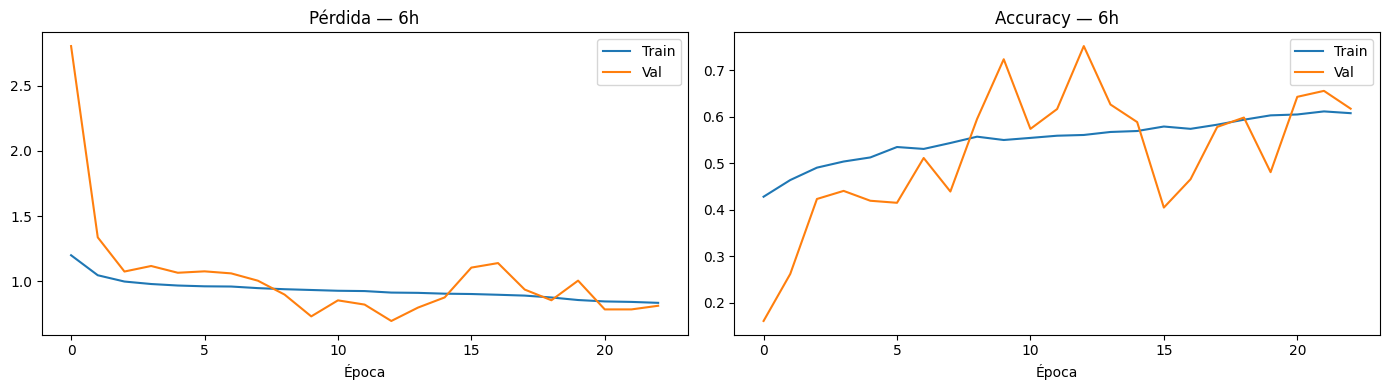

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_6h.history['loss'],     label='Train'); axes[0].plot(history_6h.history['val_loss'], label='Val')
axes[0].set_title('Pérdida — 6h'); axes[0].set_xlabel('Época'); axes[0].legend()
axes[1].plot(history_6h.history['accuracy'], label='Train'); axes[1].plot(history_6h.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy — 6h'); axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout()
plt.savefig('curvas_6h.png', dpi=120, bbox_inches='tight')
plt.show()


📊 Métricas — TNN Clasificación 6 Horas
   Accuracy    : 0.6377
   F1 Macro    : 0.4301
   F1 Weighted : 0.6689

               precision    recall  f1-score   support

   Sin lluvia       0.86      0.73      0.79      8249
  Lluvia leve       0.26      0.26      0.26      1713
Lluvia fuerte       0.16      0.44      0.24       705

     accuracy                           0.64     10667
    macro avg       0.43      0.48      0.43     10667
 weighted avg       0.72      0.64      0.67     10667



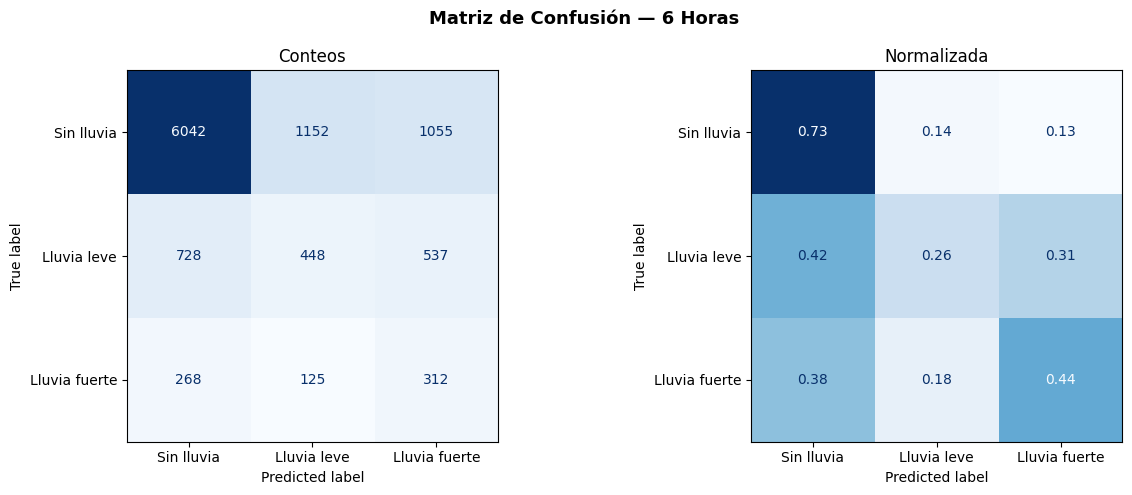

In [19]:
results_6h = evaluate_model(model_6h, X_test_6h, y_test_6h, '6 Horas')
model_6h.save('tnn_clf_balanced_6h.keras')

---
## 10. Comparación Final de los 3 Modelos


=== RESUMEN COMPARATIVO TNN CLASIFICACIÓN ===
         Accuracy  F1_Macro  F1_Weighted
horizon                                 
1 Hora   0.744378  0.538472     0.756514
3 Horas  0.616963  0.455381     0.661394
6 Horas  0.637668  0.430088     0.668950


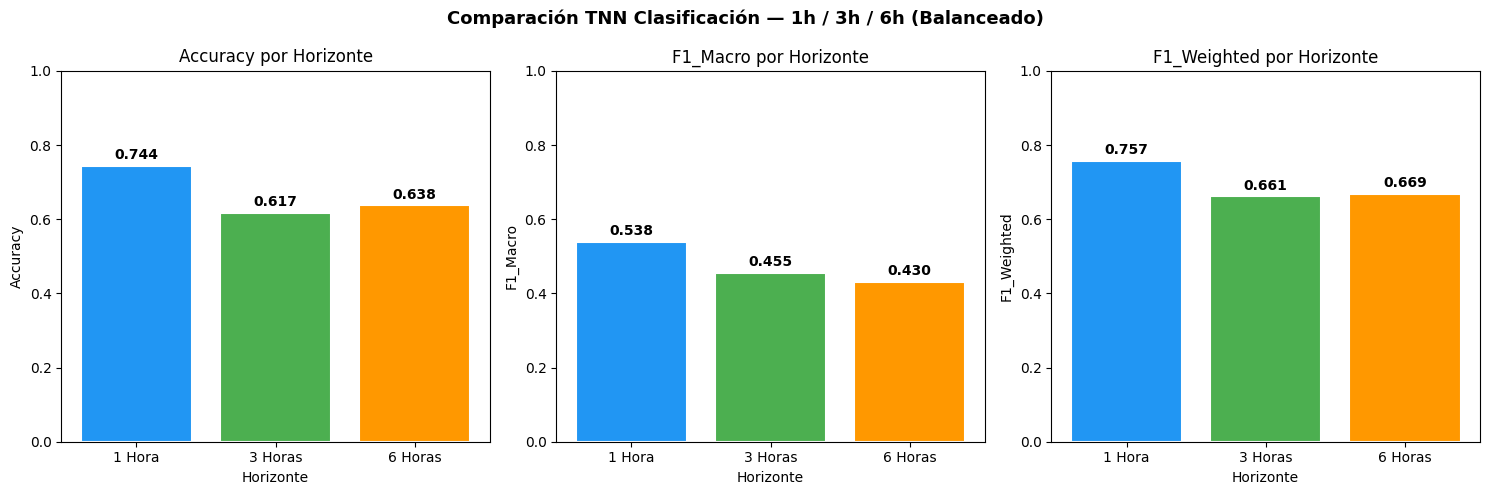

In [20]:
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_pred','y_true','y_prob']}
    for r in [results_1h, results_3h, results_6h]
]).set_index('horizon')

print('\n=== RESUMEN COMPARATIVO TNN CLASIFICACIÓN ===')
print(summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bar_colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, metric in zip(axes, ['Accuracy', 'F1_Macro', 'F1_Weighted']):
    bars = ax.bar(summary.index, summary[metric], color=bar_colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{metric} por Horizonte')
    ax.set_xlabel('Horizonte'); ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, summary[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Comparación TNN Clasificación — 1h / 3h / 6h (Balanceado)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_horizontes.png', dpi=120, bbox_inches='tight')
plt.show()

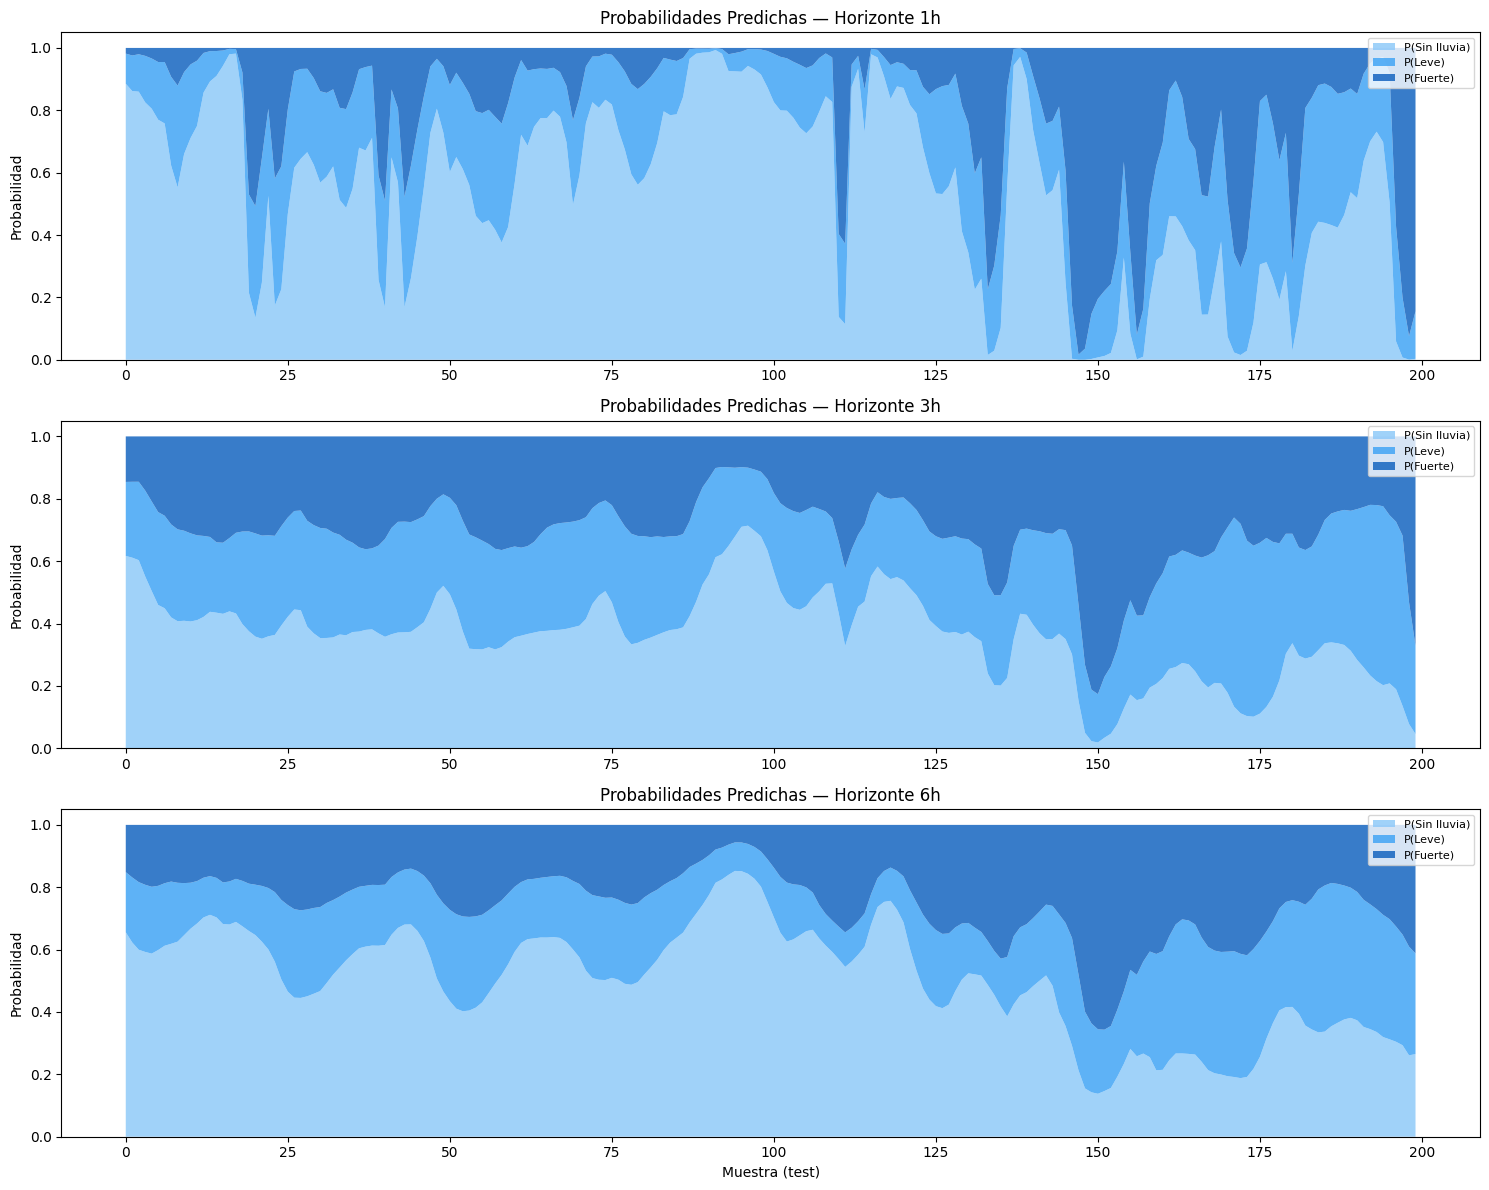

In [21]:
# Probabilidades predichas — comparación visual de los 3 horizontes
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for ax, res, label in zip(axes,
                           [results_1h, results_3h, results_6h],
                           ['1h', '3h', '6h']):
    n_show = min(200, len(res['y_prob']))
    ax.stackplot(
        range(n_show),
        res['y_prob'][:n_show, 0],
        res['y_prob'][:n_show, 1],
        res['y_prob'][:n_show, 2],
        labels=['P(Sin lluvia)', 'P(Leve)', 'P(Fuerte)'],
        colors=['#90CAF9', '#42A5F5', '#1565C0'], alpha=0.85
    )
    ax.set_title(f'Probabilidades Predichas — Horizonte {label}')
    ax.set_ylabel('Probabilidad')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Muestra (test)')
plt.tight_layout()
plt.savefig('probabilidades_3_horizontes.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Guardado Final

In [22]:
import joblib, json

joblib.dump(scaler, 'scaler_clf_balanced_JUN.pkl')

config = {
    'umbral_leve'   : UMBRAL_LEVE,
    'umbral_fuerte' : UMBRAL_FUERTE,
    'look_back'     : LOOK_BACK,
    'n_classes'     : N_CLASSES,
    'class_labels'  : class_labels,
    'features'      : data.columns.tolist(),
    'balanceo'      : 'undersample_train'
}
with open('config_clf_balanced_JUN.json', 'w') as f:
    json.dump(config, f, indent=2)

print('✅ Guardado completo:')
print('   tnn_clf_balanced_1h.keras')
print('   tnn_clf_balanced_3h.keras')
print('   tnn_clf_balanced_6h.keras')
print('   scaler_clf_balanced_JUN.pkl')
print('   config_clf_balanced_JUN.json')

✅ Guardado completo:
   tnn_clf_balanced_1h.keras
   tnn_clf_balanced_3h.keras
   tnn_clf_balanced_6h.keras
   scaler_clf_balanced_JUN.pkl
   config_clf_balanced_JUN.json


---
## 📝 Resumen Metodológico

| Etapa | Detalle |
|---|---|
| **Tarea** | Clasificación multiclase (3 clases) |
| **Clases** | 0: Sin lluvia (<0.1) \| 1: Leve (0.1–1.0) \| 2: Fuerte (>1.0 mm/h) |
| **Resampleo** | 15 min → 1h: media continuas, suma lluvia |
| **Balanceo** | Submuestreo de clase 0 en train (iguala a clase minoritaria) |
| **Val / Test** | Distribución real sin modificar |
| **Look_back** | 24 horas |
| **Horizontes** | 1h / 3h / 6h |
| **Arquitectura** | Conv1D(64→128→128) + BN + Dropout + MaxPool + Dense(128→64→3) |
| **Salida** | Dense(3, softmax) |
| **Pérdida** | categorical_crossentropy |
| **Callbacks** | EarlyStopping(patience=10) + ReduceLROnPlateau(patience=5) |
| **Métricas** | Accuracy, F1 Macro, F1 Weighted, Matriz de Confusión |